# Taller: Ingeniería de Variables + Redes Neuronales para Series de Tiempo Financieras

**Caso de estudio:** trabajas en el equipo de analítica cuantitativa de una gestora de fondos. En el cuaderno *Redes Neuronales y Deep Learning para Series de Tiempo Financieras* construiste un MLP y una LSTM que predicen el precio de una acción usando **únicamente su precio pasado**. Tu jefa de equipo pregunta algo razonable: 

"¿Y si además le damos al modelo las variables técnicas que ya usamos en analítica financiera volatilidad, RSI, Bandas de Bollinger, mejora la predicción, o el precio solo ya contiene toda la información relevante?"

Este taller responde esa pregunta de forma empírica.

1. *"Datos reales*: descarga precios históricos de un activo real (...) y repite el flujo de limpieza." — aquí lo hacemos con `yfinance`, igual que en el cuaderno de redes neuronales.
2. *"Variable de volumen relativo: construye $\text{vol\_relativo}_t = \text{Volume}_t / \text{media\_movil}_{20}(\text{Volume})_t$."*  la incluimos como una de las variables de entrada.

 **Objetivo del taller:** construir, entrenar y comparar cuatro modelos (MLP y LSTM, cada uno univariado y multivariado) frente a una línea base ingenua, para determinar si la ingeniería de variables financieras aporta poder predictivo más allá del precio crudo.

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)   # fija random de Python, NumPy y TensorFlow de una sola vez
tf.config.experimental.enable_op_determinism()  # fuerza operaciones deterministas (evita variar entre corridas)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

## 1. Descarga de datos reales

In [ ]:
TICKER = "AAPL" # Reemplaza con el activo asignado
FECHA_INICIO = "2015-01-01"

datos = yf.download(TICKER, start=FECHA_INICIO, auto_adjust=True, progress=False)
datos.columns = datos.columns.get_level_values(0)  # yfinance devuelve columnas con MultiIndex

precio = datos["Close"].asfreq("B").ffill()
volumen = datos["Volume"].asfreq("B").ffill()

print(f"Periodo: {precio.index.min().date()} -> {precio.index.max().date()}  ({len(precio)} días hábiles)")

Periodo: 2015-01-02 -> 2026-09-18  (3056 días hábiles)


## 2. Ingeniería de variables financieras

Reutilizamos, sobre datos reales, el mismo vocabulario de variables construidas en la sección 3 de *introducción.ipynb*: retornos, volatilidad histórica, RSI, Bandas de Bollinger y (siguiendo el Ejercicio propuesto 2) volumen relativo. Todas se calculan con funciones de ventana móvil (`rolling`, `ewm`) que, por construcción, solo usan información **hasta** el día en curso — respetan la regla de oro contra la fuga de información temporal de la sección 2.1 de ese cuaderno.

### 2.1 Retorno logarítmico

In [3]:
retorno = np.log(precio / precio.shift(1))

### 2.2 Volatilidad histórica móvil (21 días, anualizada)

Igual que en la sección 3.2 de *introducción.ipynb*.

In [4]:
volatilidad_21 = retorno.rolling(21).std() * np.sqrt(252)

### 2.3 RSI (14 días)

Reutilizamos exactamente la función `calcular_rsi` de la sección 3.4 de *introducción.ipynb*.

In [5]:
def calcular_rsi(serie_precios, ventana=14):
    delta = serie_precios.diff()
    ganancia = delta.clip(lower=0)
    perdida = -delta.clip(upper=0)

    ganancia_media = ganancia.rolling(ventana).mean()
    perdida_media = perdida.rolling(ventana).mean()

    rs = ganancia_media / perdida_media
    return 100 - (100 / (1 + rs))

rsi_14 = calcular_rsi(precio, ventana=14)

### 2.4 Bandas de Bollinger: %B
Convertimos las bandas  en una variable numérica normalizada: la posición del precio **dentro** de las bandas, $\%B = (P_t - \text{banda\_inf}_t) / (\text{banda\_sup}_t - \text{banda\_inf}_t)$. Valores cercanos a 1 indican precio pegado a la banda superior (posible sobrecompra); cercanos a 0, a la banda inferior.

In [6]:
w, k = 20, 2
sma_w = precio.rolling(w).mean()
std_w = precio.rolling(w).std()
banda_sup = sma_w + k * std_w
banda_inf = sma_w - k * std_w
pct_b_bollinger = (precio - banda_inf) / (banda_sup - banda_inf)

### 2.5 Volumen relativo 

In [7]:
volumen_relativo = volumen / volumen.rolling(20).mean()

### 2.6 Consolidación de la matriz de variables

Unimos todo en un solo `DataFrame`, con el precio como primera columna (la necesitamos tanto como variable de entrada como variable objetivo). Las primeras filas quedan en `NaN` porque las ventanas móviles más largas (21 días) todavía no tienen suficiente historia.

In [8]:
variables = pd.DataFrame({
    "precio": precio,
    "retorno": retorno,
    "volatilidad_21": volatilidad_21,
    "rsi_14": rsi_14,
    "pct_b_bollinger": pct_b_bollinger,
    "volumen_relativo": volumen_relativo,
}).dropna()

COLUMNAS_FEATURES = ["retorno", "volatilidad_21", "rsi_14", "pct_b_bollinger", "volumen_relativo"]

print(f"Observaciones utilizables tras descartar NaN iniciales: {len(variables)}")
variables.describe().round(3)

Observaciones utilizables tras descartar NaN iniciales: 3035


,precio,retorno,volatilidad_21,rsi_14,pct_b_bollinger,volumen_relativo
count,3035.000,3035.000,3035.000,3035.000,3035.000,3035.000
mean,117.868,0.001,0.255,55.367,0.583,1.003
std,84.161,0.018,0.121,18.258,0.328,0.371
min,20.548,-0.138,0.074,3.260,-0.299,0.319
25%,38.753,-0.007,0.179,41.600,0.313,0.773
50%,117.363,0.000,0.232,56.386,0.647,0.917
75%,177.424,0.009,0.299,69.271,0.849,1.131
max,339.787,0.143,1.069,96.833,1.373,5.184


## 3. Preparación para redes neuronales

### 3.1 División cronológica train/test

Misma proporción (80/20) y mismo criterio cronológico del cuaderno de redes neuronales.

In [9]:
FRACCION_TRAIN = 0.8
n_train = int(len(variables) * FRACCION_TRAIN)

variables_train = variables.iloc[:n_train]
variables_test = variables.iloc[n_train:]

print(f"Entrenamiento: {variables_train.index.min().date()} -> {variables_train.index.max().date()}  ({len(variables_train)} días)")
print(f"Prueba:        {variables_test.index.min().date()} -> {variables_test.index.max().date()}  ({len(variables_test)} días)")

Entrenamiento: 2015-02-02 -> 2024-05-22  (2428 días)
Prueba:        2024-05-23 -> 2026-09-18  (607 días)


### 3.2 Escalado sin fuga de información

Dos escaladores, ambos ajustados **solo con datos de entrenamiento**: uno para el precio (la variable objetivo, y también la única entrada del modelo univariado) y otro para las cinco variables técnicas.

In [10]:
escalador_precio = MinMaxScaler(feature_range=(0, 1))
escalador_features = MinMaxScaler(feature_range=(0, 1))

precio_train_esc = escalador_precio.fit_transform(variables_train[["precio"]]).flatten()
precio_test_esc = escalador_precio.transform(variables_test[["precio"]]).flatten()

features_train_esc = escalador_features.fit_transform(variables_train[COLUMNAS_FEATURES])
features_test_esc = escalador_features.transform(variables_test[COLUMNAS_FEATURES])

### 3.3 Ventanas univariadas y multivariadas

Una sola función de ventanas deslizantes, reutilizada para ambos casos: el modelo **univariado** recibe una matriz con una sola columna (el precio); el **multivariado**, una matriz con el precio y las cinco variables técnicas. Como en el cuaderno de redes neuronales, anteponemos la cola del entrenamiento para que la primera ventana de prueba tenga historia completa (son datos ya observados, no hay fuga).

In [11]:
VENTANA = 30

def crear_ventanas(matriz_escalada, ventana):
    X, y = [], []
    for i in range(ventana, len(matriz_escalada)):
        X.append(matriz_escalada[i - ventana:i, :])
        y.append(matriz_escalada[i, 0])  # columna 0 = precio, siempre la variable objetivo
    return np.array(X), np.array(y)

# --- matrices completas: columna 0 = precio, columnas 1-5 = variables técnicas ---
matriz_train = np.column_stack([precio_train_esc, features_train_esc])
matriz_test = np.column_stack([precio_test_esc, features_test_esc])
matriz_test_con_historia = np.concatenate([matriz_train[-VENTANA:], matriz_test])

# --- univariado: solo la columna del precio ---
X_train_uni, y_train = crear_ventanas(matriz_train[:, [0]], VENTANA)
X_test_uni, y_test = crear_ventanas(matriz_test_con_historia[:, [0]], VENTANA)

# --- multivariado: precio + 5 variables técnicas ---
X_train_multi, _ = crear_ventanas(matriz_train, VENTANA)
X_test_multi, _ = crear_ventanas(matriz_test_con_historia, VENTANA)

fechas_test = variables_test.index
N_FEATURES = matriz_train.shape[1]

print(f"Univariado  -> X_train: {X_train_uni.shape}   X_test: {X_test_uni.shape}")
print(f"Multivariado -> X_train: {X_train_multi.shape}   X_test: {X_test_multi.shape}")

Univariado  -> X_train: (2398, 30, 1)   X_test: (607, 30, 1)
Multivariado -> X_train: (2398, 30, 6)   X_test: (607, 30, 6)


`y_train`/`y_test` son los mismos en ambos casos (el precio escalado del día siguiente): lo único que cambia entre modelos "univariado" y "multivariado" es **cuánta información de entrada** reciben, no lo que deben predecir — así el experimento aísla el efecto de agregar las variables técnicas.

## 4. Arquitecturas reutilizables

En vez de repetir cuatro veces el código de definición y entrenamiento (una por cada combinación modelo × conjunto de variables), lo encapsulamos en funciones — la misma idea de "mover código de notebook a funciones reutilizables" que vimos en el taller de DataOps.

In [12]:
def construir_mlp(dimension_entrada):
    modelo = keras.Sequential([
        layers.Input(shape=(dimension_entrada,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear"),
    ])
    modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return modelo


def construir_lstm(ventana, n_features):
    modelo = keras.Sequential([
        layers.Input(shape=(ventana, n_features)),
        layers.LSTM(50, activation="tanh"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear"),
    ])
    # clipnorm: recorta la magnitud del gradiente en cada paso. Las LSTM son más
    # propensas que un MLP a dar, ocasionalmente, un paso de entrenamiento demasiado
    # grande que las saca de una buena región de la función de pérdida; limitar la
    # norma del gradiente es la forma estándar de estabilizar ese entrenamiento.
    optimizador = keras.optimizers.Adam(clipnorm=1.0)
    modelo.compile(optimizer=optimizador, loss="mse", metrics=["mae"])
    return modelo


def entrenar(modelo, X_train, y_train):
    # EarlyStopping detiene el entrenamiento si val_loss deja de mejorar; ReduceLROnPlateau
    # reduce la tasa de aprendizaje antes de llegar a ese punto, para darle al optimizador
    # una oportunidad de salir de una meseta en vez de quedarse estancado (más relevante
    # para la LSTM, más sensible a la inicialización que el MLP)
    callbacks = [
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ]
    historia = modelo.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=150,
        batch_size=32,
        callbacks=callbacks,
        verbose=0,
    )
    return historia

## 5. Modelos univariados (línea base: solo precio)

Misma configuración que en *redes_neuronales_series_tiempo.ipynb* — los reconstruimos aquí para que el entrenamiento y la evaluación ocurran sobre exactamente los mismos datos que los modelos multivariados.

In [13]:
mlp_uni = construir_mlp(dimension_entrada=VENTANA)
historia_mlp_uni = entrenar(mlp_uni, X_train_uni.reshape(X_train_uni.shape[0], -1), y_train)
print(f"MLP univariado — entrenamiento detenido en la época {len(historia_mlp_uni.history['loss'])}")

E0000 00:00:1789823603.614583 2443399 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


MLP univariado — entrenamiento detenido en la época 38


In [14]:
lstm_uni = construir_lstm(ventana=VENTANA, n_features=1)
historia_lstm_uni = entrenar(lstm_uni, X_train_uni, y_train)
print(f"LSTM univariada — entrenamiento detenido en la época {len(historia_lstm_uni.history['loss'])}")

LSTM univariada — entrenamiento detenido en la época 150


## 6. Modelos multivariados (precio + variables técnicas)

Misma arquitectura y mismos hiperparámetros que los modelos univariados — la única diferencia es la dimensión de entrada, que ahora incluye las cinco variables de la sección 2.

In [15]:
mlp_multi = construir_mlp(dimension_entrada=VENTANA * N_FEATURES)
historia_mlp_multi = entrenar(mlp_multi, X_train_multi.reshape(X_train_multi.shape[0], -1), y_train)
print(f"MLP multivariado — entrenamiento detenido en la época {len(historia_mlp_multi.history['loss'])}")

E0000 00:00:1789823646.534256 2443399 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


MLP multivariado — entrenamiento detenido en la época 35


In [16]:
lstm_multi = construir_lstm(ventana=VENTANA, n_features=N_FEATURES)
historia_lstm_multi = entrenar(lstm_multi, X_train_multi, y_train)
print(f"LSTM multivariada — entrenamiento detenido en la época {len(historia_lstm_multi.history['loss'])}")

LSTM multivariada — entrenamiento detenido en la época 30


## 7. ¿Ayudó la ingeniería de variables? Comparación de desempeño

Evaluamos los cuatro modelos sobre el mismo conjunto de prueba, junto con la línea base ingenua (el precio de mañana es igual al de hoy) que ya conocemos del cuaderno de redes neuronales.

In [17]:
def invertir_escala(valores_escalados):
    return escalador_precio.inverse_transform(np.asarray(valores_escalados).reshape(-1, 1)).flatten()


def calcular_metricas(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    r2 = r2_score(y_real, y_pred)
    return {"Modelo": nombre, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R²": r2}


y_test_real = invertir_escala(y_test)

predicciones = {
    "Ingenuo (random walk)": invertir_escala(X_test_uni[:, -1, 0]),
    "MLP univariado": invertir_escala(mlp_uni.predict(X_test_uni.reshape(X_test_uni.shape[0], -1), verbose=0).flatten()),
    "LSTM univariada": invertir_escala(lstm_uni.predict(X_test_uni, verbose=0).flatten()),
    "MLP multivariado": invertir_escala(mlp_multi.predict(X_test_multi.reshape(X_test_multi.shape[0], -1), verbose=0).flatten()),
    "LSTM multivariada": invertir_escala(lstm_multi.predict(X_test_multi, verbose=0).flatten()),
}

metricas = pd.DataFrame([
    calcular_metricas(y_test_real, pred, nombre) for nombre, pred in predicciones.items()
]).set_index("Modelo")

metricas.round(4)

E0000 00:00:1789823658.356718 2443399 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,RMSE,MAE,MAPE (%),R²
Modelo,,,,
Ingenuo (random walk),4.1575,2.7955,1.1510,0.9871
MLP univariado,6.1322,4.4575,1.8285,0.9719
LSTM univariada,13.0974,10.1737,3.8739,0.8720
MLP multivariado,24.3484,19.2373,7.2533,0.5575
LSTM multivariada,22.4256,18.0365,6.7706,0.6246


In [18]:
rmse_ingenuo = metricas.loc["Ingenuo (random walk)", "RMSE"]
rmse_mlp_uni, rmse_mlp_multi = metricas.loc["MLP univariado", "RMSE"], metricas.loc["MLP multivariado", "RMSE"]
rmse_lstm_uni, rmse_lstm_multi = metricas.loc["LSTM univariada", "RMSE"], metricas.loc["LSTM multivariada", "RMSE"]

print(f"MLP:  univariado RMSE={rmse_mlp_uni:.3f}  ->  multivariado RMSE={rmse_mlp_multi:.3f}  "
      f"({'mejora' if rmse_mlp_multi < rmse_mlp_uni else 'empeora'} al agregar variables técnicas)")
print(f"LSTM: univariada RMSE={rmse_lstm_uni:.3f}  ->  multivariada RMSE={rmse_lstm_multi:.3f}  "
      f"({'mejora' if rmse_lstm_multi < rmse_lstm_uni else 'empeora'} al agregar variables técnicas)")
print(f"\nLínea base ingenua: RMSE={rmse_ingenuo:.3f}")

MLP:  univariado RMSE=6.132  ->  multivariado RMSE=24.348  (empeora al agregar variables técnicas)
LSTM: univariada RMSE=13.097  ->  multivariada RMSE=22.426  (empeora al agregar variables técnicas)

Línea base ingenua: RMSE=4.158


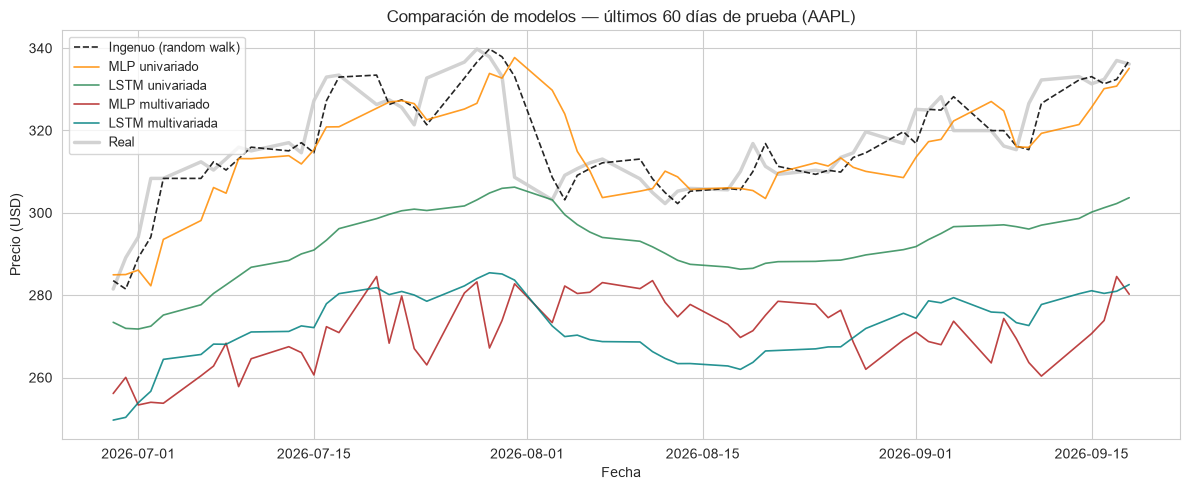

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
colores = {
    "Ingenuo (random walk)": "black",
    "MLP univariado": "darkorange",
    "LSTM univariada": "seagreen",
    "MLP multivariado": "firebrick",
    "LSTM multivariada": "teal",
}

ULTIMOS_DIAS = 60
for nombre, pred in predicciones.items():
    estilo = "--" if "Ingenuo" in nombre else "-"
    ax.plot(fechas_test[-ULTIMOS_DIAS:], pred[-ULTIMOS_DIAS:], estilo, label=nombre, color=colores[nombre], linewidth=1.2, alpha=0.85)

ax.plot(fechas_test[-ULTIMOS_DIAS:], y_test_real[-ULTIMOS_DIAS:], color="grey", linewidth=2.5, alpha=0.35, label="Real", zorder=0)
ax.set_title(f"Comparación de modelos — últimos {ULTIMOS_DIAS} días de prueba ({TICKER})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Predicción *one-step-ahead* con el mejor modelo

Usamos el modelo con menor RMSE en la sección anterior para proyectar el precio del siguiente día hábil, con los datos más recientes disponibles.

In [20]:
mejor_modelo_nombre = metricas["RMSE"].idxmin()
print(f"Mejor modelo por RMSE: {mejor_modelo_nombre}")

modelos_entrenados = {
    "MLP univariado": (mlp_uni, "uni", "mlp"),
    "LSTM univariada": (lstm_uni, "uni", "lstm"),
    "MLP multivariado": (mlp_multi, "multi", "mlp"),
    "LSTM multivariada": (lstm_multi, "multi", "lstm"),
}

if mejor_modelo_nombre == "Ingenuo (random walk)":
    prediccion_manana = variables["precio"].iloc[-1]
else:
    modelo_elegido, tipo_variables, arquitectura = modelos_entrenados[mejor_modelo_nombre]

    ultima_ventana_precio = escalador_precio.transform(variables[["precio"]].iloc[-VENTANA:]).flatten()
    ultima_ventana_features = escalador_features.transform(variables[COLUMNAS_FEATURES].iloc[-VENTANA:])
    ultima_ventana = np.column_stack([ultima_ventana_precio, ultima_ventana_features])

    entrada = ultima_ventana[:, [0]] if tipo_variables == "uni" else ultima_ventana
    entrada = entrada.reshape(1, -1) if arquitectura == "mlp" else entrada.reshape(1, VENTANA, entrada.shape[1])

    prediccion_manana = invertir_escala(modelo_elegido.predict(entrada, verbose=0).flatten())[0]

ultimo_precio = variables["precio"].iloc[-1]
ultima_fecha = variables.index[-1]

print(f"Último cierre disponible: {ultimo_precio:.2f} USD ({ultima_fecha.date()})")
print(f"Predicción para el siguiente día hábil ({mejor_modelo_nombre}): {prediccion_manana:.2f} USD "
      f"({(prediccion_manana/ultimo_precio - 1)*100:+.3f}%)")

Mejor modelo por RMSE: Ingenuo (random walk)
Último cierre disponible: 336.13 USD (2026-09-18)
Predicción para el siguiente día hábil (Ingenuo (random walk)): 336.13 USD (+0.000%)


## 9. Cierre: preguntas y ejercicios propuestos

1. Elige uno de los siguientes Tickets para realizar tu propio taller: { MSFT, JPM, XOM, SPY, SAP.DE, NESN.SW, 7203.T, 0700.HK, CIB, VALE, GC=F }

2. **Interpreta tu propio resultado.** Con los números de la sección 7 delante: ¿la ingeniería de variables mejoró el MLP, la LSTM, ninguno, o ambos? ¿El modelo con mejor RMSE fue también el que mejor "sigue" visualmente al precio real en la gráfica de la sección 7?
2. **Importancia de variables.** Los modelos de esta sección no exponen directamente qué variable pesó más (a diferencia del `RandomForestClassifier` de la sección 3.8 de *introducción.ipynb*, con su gráfico de importancias). Entrena un `RandomForestRegressor` de `scikit-learn` sobre las mismas ventanas multivariadas (aplanadas) y compara su `feature_importances_` con la mejora — o no — que viste en las redes neuronales.
3. **Otra variable técnica.** *introducción.ipynb* también construye MACD y *drawdown* (secciones 3.3 y 3.6) que no incluimos aquí. Agrega una de las dos al `DataFrame` de variables de la sección 2.6 y repite el experimento: ¿cambia la conclusión?
4. **Acierto direccional.** El RMSE mide error de magnitud, no si el modelo acertó la *dirección* del movimiento (subida/bajada) — que es, en la práctica, lo que importaría para una estrategia de *trading*. Calcula el porcentaje de veces que cada modelo acierta el signo de `precio_mañana - precio_hoy` y compáralo con el ranking por RMSE de la sección 7. ¿Es el mismo modelo el mejor en ambos criterios?
